# Jean pockets

Are women jean pockets ridiculously small? Let's look at the data!

The file `jean-pocket-measurements.csv` shows pocket measurements for 20 popular brands.
Four pairs of jeans from each brand were measured: men's and women's skinny and straight styles. All jeans were designated a 32-inch waistband. 

The following measurements are included:
- `height_front`: maximum front pocket height (cm)
- `height_back`: maximum back pocket height (cm)
- `width_front`: maximum front pocket width (cm)
- `width_back`: maximum back pocket width (cm)

In [40]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'jean-pocket-measurements.csv'.

# from google.colab import files
# uploaded = files.upload()

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('../data/jean-pocket-measurements.csv')
df.head()


,brand,style,gender,height_front,width_front,height_back,width_back
0,3fe5003e,skinny,women,14.5,16.5,15.0,13.7
1,3fe5003e,straight,women,14.5,16.0,15.5,13.0
2,790c6eab,skinny,women,13.0,14.5,15.5,13.5
3,790c6eab,straight,women,13.0,14.5,14.5,13.0
4,26aaf627,skinny,women,13.0,14.0,14.0,14.2


### Project Ideas

- What is the average difference in pocket `height_front` between women's and men's jeans?

- Is there a significant difference in pocket `height_front` between skinny and straight styles within the same gender?

- How do back pocket sizes compare between women's and men's jeans?

- Measure your phone's height. What percentage of women's and men's jeans can comfortably fit your phone in the pockets?



## - What is the average difference in pocket `height_front` between women's and men's jeans?

In [26]:
average_gender_height_front_difference = df.groupby('gender')['height_front'].mean()

In [27]:
average_gender_height_front_difference

gender
men      23.1300
women    14.3275
Name: height_front, dtype: float64

In [28]:
women_hf_mean = df[df['gender'] == 'women']['height_front'].mean()
men_hf_mean = df[df['gender'] == 'men']['height_front'].mean()

hf_difference = round(men_hf_mean - women_hf_mean, 4)
hf_difference

np.float64(8.8025)

#### Since value is positive hence men's pocket are taller

### - Is there a significant difference in pocket `height_front` between skinny and straight styles within the same gender?

### Finding difference for women

In [29]:
women = df[df['gender'] == 'women']
women_skinny = women[women['style'] == 'skinny']['height_front']
women_straight = women[women['style'] == 'straight']['height_front']

In [30]:
from scipy.stats import ttest_ind

ttest_ind(women_skinny, women_straight)

TtestResult(statistic=np.float64(-0.17115809415789315), pvalue=np.float64(0.8650076245237605), df=np.float64(38.0))

### Finding difference for men

In [31]:
men = df[df['gender'] == 'men']
men_skinny = men[men['style'] == 'skinny']['height_front']
men_straight = men[men['style'] == 'straight']['height_front']

In [32]:
from scipy.stats import ttest_ind

ttest_ind(men_skinny, men_straight)

TtestResult(statistic=np.float64(0.1667094755117798), pvalue=np.float64(0.8684825879248874), df=np.float64(38.0))

### How do back pocket sizes compare between women's and men's jeans?

In [33]:
df['back_pocket'] = df['height_back'] * df['width_back']
df

,brand,style,gender,height_front,width_front,height_back,width_back,back_pocket
0,3fe5003e,skinny,women,14.5,16.5,15.0,13.7,205.50
1,3fe5003e,straight,women,14.5,16.0,15.5,13.0,201.50
2,790c6eab,skinny,women,13.0,14.5,15.5,13.5,209.25
3,790c6eab,straight,women,13.0,14.5,14.5,13.0,188.50
4,26aaf627,skinny,women,13.0,14.0,14.0,14.2,198.80
...,...,...,...,...,...,...,...,...
75,afb94ef0,straight,men,28.0,13.0,16.7,14.5,242.15
76,49d2b8a1,straight,women,15.0,16.0,14.5,13.5,195.75
77,49d2b8a1,skinny,women,14.5,16.0,14.0,14.0,196.00
78,49d2b8a1,straight,men,21.0,18.5,16.0,13.0,208.00


In [34]:
df.groupby('gender')['back_pocket'].mean()

gender
men      219.70875
women    201.82125
Name: back_pocket, dtype: float64

### Measure your phone's height. What percentage of women's and men's jeans can comfortably fit your phone in the pockets?

In [35]:
phone_height = 14.67 #iPhone 12

In [36]:
df['phone_fits'] = df['height_front'] >= phone_height
df.groupby('gender')['phone_fits'].mean()*100

gender
men      100.0
women     30.0
Name: phone_fits, dtype: float64

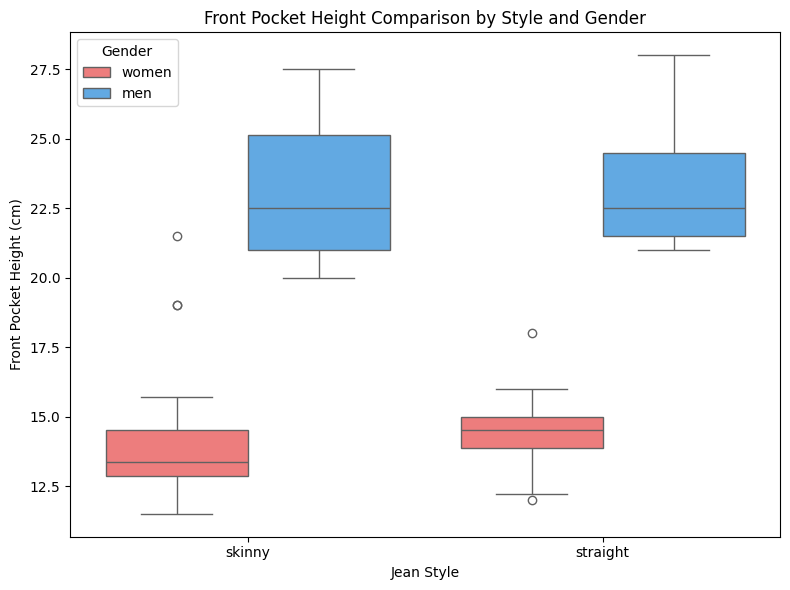

In [41]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='style',
    y='height_front',
    hue='gender',
    data=df,
    palette=['#ff6b6b','#4dabf7']
)

plt.title('Front Pocket Height Comparison by Style and Gender')
plt.xlabel('Jean Style')
plt.ylabel('Front Pocket Height (cm)')
plt.legend(title='Gender')

plt.tight_layout()
plt.show()

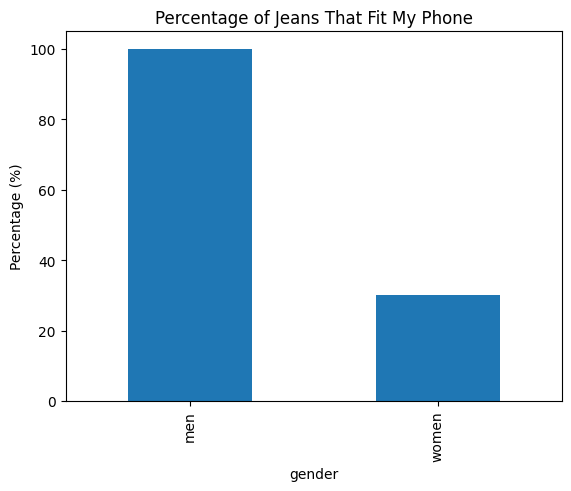

In [38]:
df.groupby('gender')['phone_fits'].mean().mul(100).plot(kind='bar')
plt.title('Percentage of Jeans That Fit My Phone')
plt.ylabel('Percentage (%)')
plt.show()